In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

In [5]:


engagement_columns = ['View Count', 'Like Count', 'Comment Count']
clustered_data = pd.read_csv("clustered_data.csv")
results_with_error = pd.read_csv("Results_Count_Final.csv")


merged_data = pd.merge(
    clustered_data,
    results_with_error[['Video_ID'] + engagement_columns],
    left_on='Video_ID',
    right_on='Video_ID',
    how='inner'
)


au_columns = [col for col in merged_data.columns if col.startswith('AU')]


print("Dataset Overview:")
print("-----------------")
print(f"Total rows: {len(merged_data)}")
print(f"Total columns: {len(merged_data.columns)}")
print("\nColumns in dataset:")
print(merged_data.columns.tolist())


print("\nBasic statistics for engagement metrics:")
print(merged_data[engagement_columns].describe())

print("\nMissing values check:")
print(merged_data.isnull().sum())


merged_data.to_csv("merged_au_engagement_data.csv", index=False)

Dataset Overview:
-----------------
Total rows: 2293
Total columns: 22

Columns in dataset:
['Video_ID', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'cluster', 'View Count', 'Like Count', 'Comment Count']

Basic statistics for engagement metrics:
         View Count    Like Count  Comment Count
count  2.293000e+03  2.293000e+03    2293.000000
mean   5.176265e+05  1.173715e+04     981.120366
std    4.182694e+06  7.348742e+04    6578.604064
min    0.000000e+00  0.000000e+00       0.000000
25%    9.518000e+03  3.980000e+02      58.000000
50%    5.475000e+04  2.024000e+03     193.000000
75%    2.260380e+05  7.228000e+03     587.000000
max    1.551887e+08  2.621954e+06  250337.000000

Missing values check:
Video_ID         0
AU01_r           0
AU02_r           0
AU04_r           0
AU05_r           0
AU06_r           0
AU07_r           0
AU09_r           0
AU10_r     

In [ ]:
# Load the CSV files
df_channels = pd.read_csv('cleaned-with-channels.csv')
df_subs = pd.read_csv('Final_Suscribers_Count.csv')
df_cluster = pd.read_csv('clustered_data.csv')

# Standardize column names for merging
df_channels.rename(columns={'Video Id': 'Video_ID', 'Channel Id': 'Channel_ID'}, inplace=True)
df_subs.rename(columns={'Channel Id': 'Channel_ID'}, inplace=True)
df_cluster.rename(columns={'Video ID': 'Video_ID'}, inplace=True)

# Merge cleaned-with-channels and Final_Suscribers_Count on Channel_ID
merged1 = pd.merge(df_channels, df_subs, on='Channel_ID', how='left')

# Merge the result with clustered_data on Video_ID
final_merged = pd.merge(merged1, df_cluster, on='Video_ID', how='left')

# Save to new CSV
final_merged.to_csv('merged_all_data.csv', index=False)
print("Merged CSV saved as 'merged_all_data.csv'")

Merged CSV saved as 'merged_all_data.csv'


In [ ]:

print(final_merged.head())

      Video_ID                Channel_ID             Channel Name  \
0  --8n6A8Q6M0  UCWm__g4cPmX-umorqM8VfWw  Travel with Luke Damant   
1  -0FfyNZdHk0  UCR-yUQRWEciSqQowtTDHskA        Learn with Daryll   
2  -1B7cVoZr1c  UCUB6A2YY9soreMGNwDLh-zw      Combat Arms Channel   
3  -4yu_13EHFM  UCFvQ_bDaalb-1ZyCb48LCpA         Chasing Kimberly   
4  -6FvAU9H98w  UCixD9UbKvDxzGNiPC_fgHyA          Paolo fromTOKYO   

   Subscriber Count  AU01_r  AU02_r  AU04_r  AU05_r  AU06_r  AU07_r  ...  \
0         1620000.0   1.080    0.00   0.000   1.870   1.220   1.770  ...   
1            5250.0   0.055    0.00   0.000   0.920   1.340   0.755  ...   
2          589000.0   0.875    0.00   0.705   0.515   0.425   0.935  ...   
3           16500.0   0.920    0.17   0.000   0.010   0.160   0.640  ...   
4         3620000.0   2.770    1.90   0.000   0.890   1.570   0.660  ...   

   AU12_r  AU14_r  AU15_r  AU17_r  AU20_r  AU23_r  AU25_r  AU26_r  AU45_r  \
0    1.22   0.560   0.000   0.000    0.29   0.000  

In [57]:
# Group by face cluster and channel, then count videos
cluster_channel_counts = final_merged.groupby(['cluster', 'Channel Name']).size().reset_index(name='Video Count')

# Sort by cluster and video count in descending order
cluster_channel_counts = cluster_channel_counts.sort_values(['cluster', 'Video Count'], ascending=[True, False])

# Create a list to store the top 10 channels per cluster
top_channels = []

# Get top 10 channels for each cluster
for cluster in sorted(cluster_channel_counts['cluster'].unique()):
    # Get top 10 channels for this cluster
    cluster_data = cluster_channel_counts[cluster_channel_counts['cluster'] == cluster].nlargest(5, 'Video Count')
    
    # Add cluster header
    top_channels.append({
        'Cluster': f"Cluster {cluster}",
        'Channel': '---',
        'Video Count': '---'
    })
    
    # Add top 10 channels
    for _, row in cluster_data.iterrows():
        top_channels.append({
            'Cluster': '',
            'Channel': row['Channel Name'],
            'Video Count': row['Video Count']
        })

# Create DataFrame from formatted results
result_df = pd.DataFrame(top_channels)

# Save to CSV
result_df.to_csv('top_channels_per_face_cluster.csv', index=False)

# Print the results
print("\nTop 5 channels per face cluster:")
for cluster in sorted(cluster_channel_counts['cluster'].unique()):
    cluster_data = cluster_channel_counts[cluster_channel_counts['cluster'] == cluster].nlargest(5, 'Video Count')
    print(f"\nCluster {cluster}:")
    for _, row in cluster_data.iterrows():
        print(f"Channel: {row['Channel Name']} - Videos: {row['Video Count']}")


Top 5 channels per face cluster:

Cluster 0.0:
Channel: Pinoy Planet - Videos: 33
Channel: Nic & Rei - Videos: 26
Channel: Adam and Jane's Lifestyle - Videos: 18
Channel: Justin & Alina - Videos: 13
Channel: The Love Train Nation - Videos: 11

Cluster 1.0:
Channel: Waleska Herrera - Videos: 138
Channel: The Commodity - Videos: 40
Channel: RETIRING IN PARADISE - Videos: 37
Channel: Pinoy Planet - Videos: 36
Channel: Adam and Jane's Lifestyle - Videos: 26

Cluster 2.0:
Channel: TriFate Geo - Videos: 30
Channel: Pinoy Planet - Videos: 15
Channel: Beryl Shereshewsky - Videos: 9
Channel: Music Game News - Videos: 8
Channel: The Demouchets REACT - Videos: 6


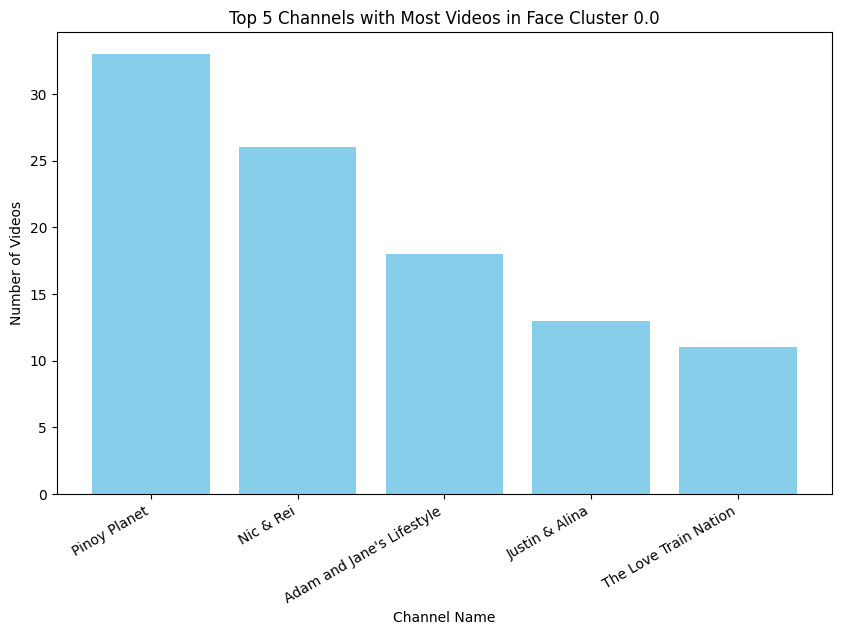

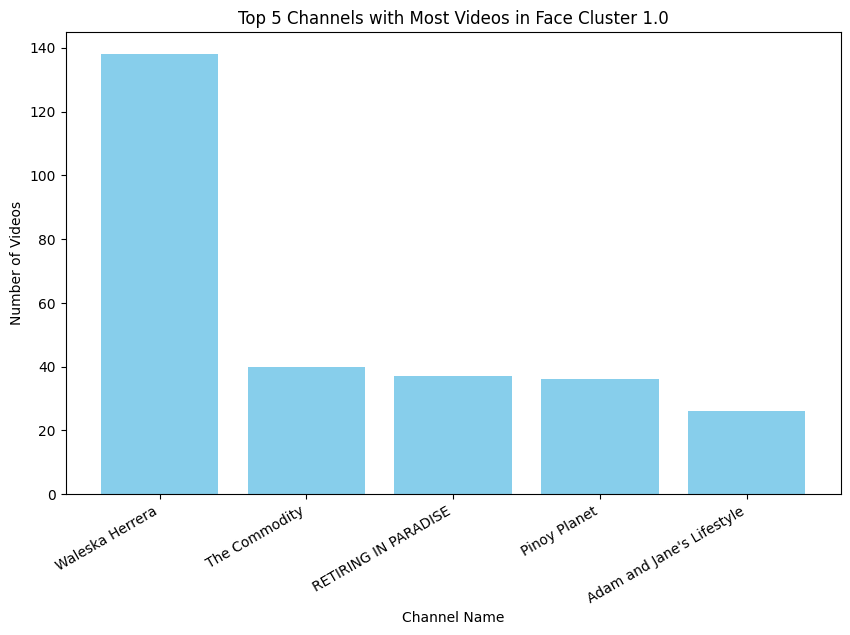

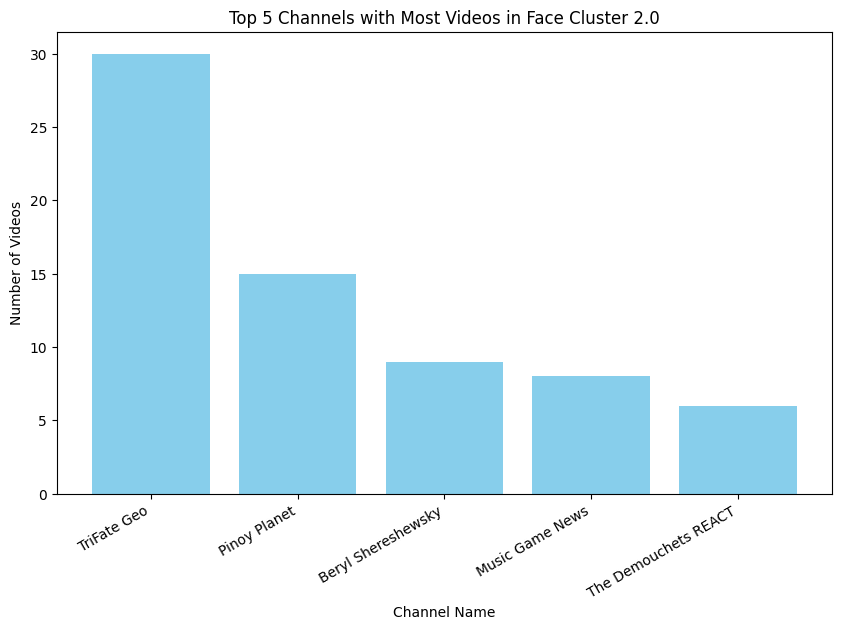

In [ ]:


cluster_channel_counts = final_merged.groupby(['cluster', 'Channel Name']).size().reset_index(name='Video Count')

# Sort by cluster and video count in descending order
cluster_channel_counts = cluster_channel_counts.sort_values(['cluster', 'Video Count'], ascending=[True, False])

clusters = sorted(cluster_channel_counts['cluster'].unique())
for cluster in clusters:
    cluster_data = cluster_channel_counts[cluster_channel_counts['cluster'] == cluster]
    # Get top 5 channels for this cluster
    top5 = cluster_data.nlargest(5, 'Video Count')[['Channel Name', 'Video Count']]
    
    plt.figure(figsize=(10, 6))
    plt.bar(top5['Channel Name'], top5['Video Count'], color='skyblue')
    plt.title(f'Top 5 Channels with Most Videos in Face Cluster {cluster}')
    plt.xlabel('Channel Name')
    plt.ylabel('Number of Videos')
    plt.xticks(rotation=30, ha='right')

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate channel frequencies across the entire dataset
channel_frequencies = final_merged.groupby('Channel Name').size()
total_videos = len(final_merged)

# Calculate weights (inverse of frequency, add 1 to avoid division by zero)
channel_weights = 1 / (channel_frequencies + 1)

# Normalize weights to sum to 1
channel_weights = channel_weights / channel_weights.sum()

# Add weights to the dataset
weighted_data = final_merged.copy()
weighted_data['Channel_Weight'] = weighted_data['Channel Name'].map(channel_weights)

# Print some statistics about the weights
print("\nChannel Weight Statistics:")
print("------------------------")
print(f"Number of unique channels: {len(channel_weights)}")
print(f"Minimum weight: {channel_weights.min():.6f}")
print(f"Maximum weight: {channel_weights.max():.6f}")
print(f"Mean weight: {channel_weights.mean():.6f}")

# Show example of weights for some channels
print("\nExample Channel Weights:")
print("----------------------")
example_channels = channel_weights.nlargest(5).index.tolist() + channel_weights.nsmallest(5).index.tolist()
for channel in example_channels:
    print(f"{channel}:")
    print(f"  Frequency: {channel_frequencies[channel]} videos")
    print(f"  Weight: {channel_weights[channel]:.6f}")

# Calculate weighted statistics for numeric columns
numeric_columns = weighted_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col not in ['cluster', 'Channel_Weight']]

# Calculate weighted means for each cluster
weighted_cluster_stats = []
for cluster in sorted(weighted_data['cluster'].unique()):
    cluster_data = weighted_data[weighted_data['cluster'] == cluster]
    weight_sum = cluster_data['Channel_Weight'].sum()
    if len(cluster_data) == 0 or weight_sum == 0:
        print(f"Skipping cluster {cluster} (no data or weights sum to zero).")
        continue
    weighted_stats = {
        'Cluster': cluster,
        'Total_Videos': len(cluster_data),
        'Unique_Channels': len(cluster_data['Channel Name'].unique())
    }
    for column in numeric_columns:
        weighted_mean = np.average(cluster_data[column], weights=cluster_data['Channel_Weight'])
        weighted_stats[f'Weighted_Mean_{column}'] = weighted_mean
    weighted_cluster_stats.append(weighted_stats)

# Convert to DataFrame
weighted_stats_df = pd.DataFrame(weighted_cluster_stats)

# Save the weighted dataset and statistics
weighted_data.to_csv('channel_weighted_data.csv', index=False)
weighted_stats_df.to_csv('weighted_cluster_statistics.csv', index=False)

# Print weighted cluster statistics
print("\nWeighted Cluster Statistics:")
print("--------------------------")
print(weighted_stats_df)

# Print summary of the weighted analysis
print("\nSummary of Weighted Analysis:")
print("---------------------------")
print(f"Total videos analyzed: {len(weighted_data)}")
print(f"Total unique channels: {len(channel_weights)}")
print(f"Average videos per channel: {channel_frequencies.mean():.2f}")
print(f"Median videos per channel: {channel_frequencies.median():.2f}")
print(f"Maximum videos per channel: {channel_frequencies.max()}")
print(f"Minimum videos per channel: {channel_frequencies.min()}")


Channel Weight Statistics:
------------------------
Number of unique channels: 922
Minimum weight: 0.000021
Maximum weight: 0.001639
Mean weight: 0.001085

Example Channel Weights:
----------------------
 🌻Mia's Kitchen🌻:
  Frequency: 1 videos
  Weight: 0.001639
10 Tampa Bay:
  Frequency: 1 videos
  Weight: 0.001639
1000 Nomads:
  Frequency: 1 videos
  Weight: 0.001639
1001 Trips - #1001Trips:
  Frequency: 1 videos
  Weight: 0.001639
2 French in Manila:
  Frequency: 1 videos
  Weight: 0.001639
Waleska Herrera:
  Frequency: 157 videos
  Weight: 0.000021
What's up Philippines:
  Frequency: 124 videos
  Weight: 0.000026
Pinoy Planet:
  Frequency: 90 videos
  Weight: 0.000036
A Foreigner in the Philippines:
  Frequency: 59 videos
  Weight: 0.000055
The Commodity:
  Frequency: 52 videos
  Weight: 0.000062
Skipping cluster nan (no data or weights sum to zero).

Weighted Cluster Statistics:
--------------------------
   Cluster  Total_Videos  Unique_Channels  Weighted_Mean_Subscriber Count  


===== ANOVA Analysis of Clusters (Raw Data, No Outliers) =====


C:\Users\alexa\AppData\Local\Temp\ipykernel_26672\3275362676.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_data, x='cluster', y=metric,
C:\Users\alexa\AppData\Local\Temp\ipykernel_26672\3275362676.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_data, x='cluster', y=metric,
C:\Users\alexa\AppData\Local\Temp\ipykernel_26672\3275362676.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_data, x='cluster', y=metric,


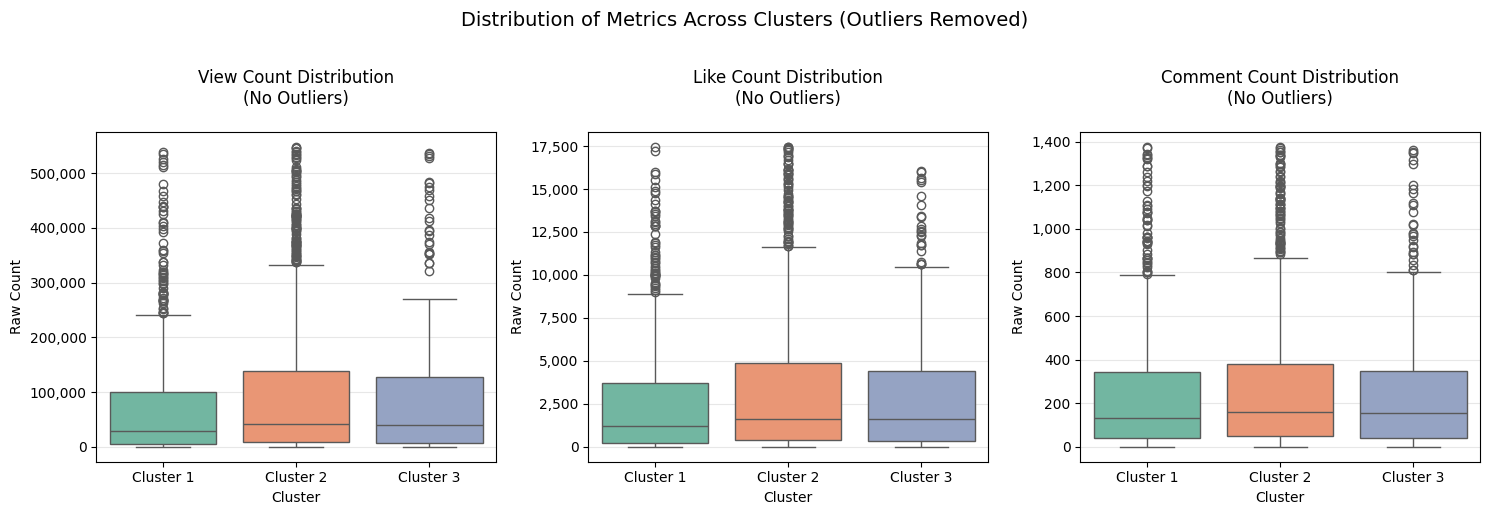


Detailed ANOVA Results:

View Count:
• F-statistic: 6.380
• P-value: 0.0017
• Effect size (η²): 0.006
• Cluster 1 mean: 76,303 (n=626)
• Cluster 2 mean: 97,548 (n=1126)
• Cluster 3 mean: 95,615 (n=234)
• Significant: Yes

Like Count:
• F-statistic: 5.119
• P-value: 0.0061
• Effect size (η²): 0.005
• Cluster 1 mean: 2,730 (n=639)
• Cluster 2 mean: 3,335 (n=1144)
• Cluster 3 mean: 3,317 (n=237)
• Significant: Yes

Comment Count:
• F-statistic: 0.648
• P-value: 0.5229
• Effect size (η²): 0.001
• Cluster 1 mean: 257 (n=630)
• Cluster 2 mean: 270 (n=1145)
• Cluster 3 mean: 281 (n=232)
• Significant: No


In [9]:
def analyze_clusters_anova_raw(merged_data):
    """
    Perform ANOVA analysis for engagement metrics between clusters
    Using raw data with outlier removal
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    import pandas as pd

    engagement_metrics = ['View Count', 'Like Count', 'Comment Count']
    results = []

    print("\n===== ANOVA Analysis of Clusters (Raw Data, No Outliers) =====")

    clusters = sorted(merged_data['cluster'].unique())
    fig, axes = plt.subplots(1, len(engagement_metrics), figsize=(5 * len(engagement_metrics), 5))

    for i, metric in enumerate(engagement_metrics):
        Q1 = merged_data[metric].quantile(0.25)
        Q3 = merged_data[metric].quantile(0.75)
        IQR = Q3 - Q1
        filtered_data = merged_data[
            (merged_data[metric] >= Q1 - 1.5 * IQR) &
            (merged_data[metric] <= Q3 + 1.5 * IQR)
        ]

        # Prepare data for ANOVA
        cluster_data_list = [filtered_data[filtered_data['cluster'] == c][metric] for c in clusters]
        cluster_data_list = [d for d in cluster_data_list if len(d) > 0]

        if len(cluster_data_list) < 2:
            print(f"Not enough clusters with data for {metric}. Skipping.")
            continue

        f_stat, p_value = stats.f_oneway(*cluster_data_list)

        metric_mean = filtered_data[metric].mean()
        ss_between = sum(len(group) * ((group.mean() - metric_mean) ** 2) for group in cluster_data_list)
        ss_total = sum((filtered_data[metric] - metric_mean) ** 2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0

        means = [f"{group.mean():,.0f}" for group in cluster_data_list]
        counts = [len(group) for group in cluster_data_list]

        results.append({
            'Metric': metric,
            'F_statistic': f_stat,
            'P_value': p_value,
            'Effect_size': eta_squared,
            'Significant': p_value < 0.05,
            **{f"Mean_Cluster{c+1}": means[j] for j, c in enumerate(clusters)},
            **{f"N_Cluster{c+1}": counts[j] for j, c in enumerate(clusters)}
        })

        axes[i].grid(True, alpha=0.3)
        sns.boxplot(data=filtered_data, x='cluster', y=metric,
                    ax=axes[i],
                    palette=sns.color_palette("Set2", n_colors=len(clusters)))
        axes[i].set_title(f'{metric} Distribution\n(No Outliers)', pad=20)
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Raw Count')
        axes[i].set_xticks(range(len(clusters)))
        axes[i].set_xticklabels([f'Cluster {c+1}' for c in clusters])
        axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.suptitle('Distribution of Metrics Across Clusters (Outliers Removed)',
                 y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)

    print("\nDetailed ANOVA Results:")
    print("=" * 50)
    for _, row in results_df.iterrows():
        print(f"\n{row['Metric']}:")
        print(f"• F-statistic: {row['F_statistic']:.3f}")
        print(f"• P-value: {row['P_value']:.4f}")
        print(f"• Effect size (η²): {row['Effect_size']:.3f}")
        for c in clusters:
            mean_key = f"Mean_Cluster{c+1}"
            n_key = f"N_Cluster{c+1}"
            if mean_key in row and n_key in row:
                print(f"• Cluster {c+1} mean: {row[mean_key]} (n={row[n_key]})")
        print(f"• Significant: {'Yes' if row['Significant'] else 'No'}")

    return results_df

anova_results_raw = analyze_clusters_anova_raw(merged_data)
anova_results_raw.to_csv('cluster_anova_results_raw.csv', index=False)

In [27]:
print(weighted_data.columns.tolist())

['Video_ID', 'Channel_ID', 'Channel Name', 'Subscriber Count', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'cluster', 'Channel_Weight']


In [31]:
# Merge engagement columns into final_merged before weighting
engagement_columns = ['View Count', 'Like Count', 'Comment Count']
results_with_error = pd.read_csv("Results_Count_Final.csv")
final_merged = pd.merge(
    final_merged,
    results_with_error[['Video_ID'] + engagement_columns],
    left_on='Video_ID',
    right_on='Video_ID',
    how='left'
)

In [32]:
weighted_data = final_merged.copy()
weighted_data['Channel_Weight'] = weighted_data['Channel Name'].map(channel_weights)

In [33]:
clean_view_data = weighted_data[['cluster', 'View Count', 'Channel_Weight']].copy()
clean_view_data.rename(columns={'cluster': 'Cluster'}, inplace=True)

In [38]:
print(clean_view_data[['Cluster', 'View Count', 'Channel_Weight']].isna().sum())


Cluster           1495
View Count         121
Channel_Weight      23
dtype: int64


In [39]:
clean_view_data = clean_view_data.dropna(subset=['View Count', 'Channel_Weight'])


In [40]:
for cluster in clusters:
    cluster_df = clean_view_data[clean_view_data['Cluster'] == cluster]

    if cluster_df.empty:
        print(f"  Cluster {cluster}: No data.")
        continue

    if cluster_df['Channel_Weight'].isnull().any():
        print(f"  Cluster {cluster}: Has NaN in Channel_Weight.")
    if cluster_df['View Count'].isnull().any():
        print(f"  Cluster {cluster}: Has NaN in View Count.")
    
    weight_sum = cluster_df['Channel_Weight'].sum()

    if weight_sum == 0:
        print(f"  Cluster {cluster}: Weights sum to zero.")
        continue

    weighted_mean = np.average(cluster_df['View Count'], weights=cluster_df['Channel_Weight'])
    print(f"  Cluster {cluster}: {weighted_mean:,.0f} views")


  Cluster 0.0: 281,646 views
  Cluster 1.0: 554,547 views
  Cluster 2.0: 354,130 views
  Cluster nan: No data.


In [41]:
clean_view_data['Cluster'] = pd.to_numeric(clean_view_data['Cluster'], errors='coerce')


In [42]:
clean_view_data = clean_view_data[clean_view_data['Cluster'].notna()]


In [ ]:


# Choose your metric
metric = 'View Count'  # or 'Like Count', 'Comment Count'
clusters = clean_view_data['Cluster'].dropna().unique()

# Get all unique pairs of clusters
cluster_pairs = list(combinations(clusters, 2))

# Store test results
p_values = []
pair_labels = []

# Perform t-tests between each cluster pair
for cluster1, cluster2 in cluster_pairs:
    data1 = clean_view_data[clean_view_data['Cluster'] == cluster1][metric]
    data2 = clean_view_data[clean_view_data['Cluster'] == cluster2][metric]

    # Optional: remove outliers or log-transform if highly skewed
    stat, p = ttest_ind(data1, data2, equal_var=False, nan_policy='omit')
    p_values.append(p)
    pair_labels.append(f"{cluster1:.0f} vs {cluster2:.0f}")

# Apply Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')

# Combine and display results
bonferroni_results = pd.DataFrame({
    'Comparison': pair_labels,
    'Raw p-value': p_values,
    'Corrected p-value': pvals_corrected,
    'Significant (Bonferroni)': reject
})

# Sort by p-value
bonferroni_results = bonferroni_results.sort_values(by='Corrected p-value')

print(bonferroni_results)


  Comparison  Raw p-value  Corrected p-value  Significant (Bonferroni)
0     0 vs 1     0.012334           0.037002                      True
2     1 vs 2     0.026160           0.078481                     False
1     0 vs 2     0.515513           1.000000                     False


In [49]:
# Ensure clean_view_data includes all metrics
clean_view_data = weighted_data[['cluster', 'View Count', 'Like Count', 'Comment Count', 'Channel_Weight']].copy()
clean_view_data.rename(columns={'cluster': 'Cluster'}, inplace=True)
clean_view_data = clean_view_data.dropna(subset=['View Count', 'Like Count', 'Comment Count', 'Channel_Weight'])
clean_view_data['Cluster'] = pd.to_numeric(clean_view_data['Cluster'], errors='coerce')
clean_view_data = clean_view_data[clean_view_data['Cluster'].notna()]

import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

metrics = ['View Count', 'Like Count', 'Comment Count']
all_results = []

for metric in metrics:
    clusters = clean_view_data['Cluster'].dropna().unique()
    cluster_pairs = list(combinations(clusters, 2))
    results = []

    for cluster1, cluster2 in cluster_pairs:
        data1 = clean_view_data[clean_view_data['Cluster'] == cluster1][metric].dropna()
        data2 = clean_view_data[clean_view_data['Cluster'] == cluster2][metric].dropna()
        n1, n2 = len(data1), len(data2)
        mean1 = data1.mean() if n1 > 0 else np.nan
        mean2 = data2.mean() if n2 > 0 else np.nan

        if n1 == 0 or n2 == 0:
            stat, p = np.nan, np.nan
        else:
            stat, p = ttest_ind(data1, data2, equal_var=False, nan_policy='omit')

        results.append({
            'Metric': metric,
            'Comparison': f"{cluster1:.0f} vs {cluster2:.0f}",
            'N1': n1,
            'Mean1': mean1,
            'N2': n2,
            'Mean2': mean2,
            'Raw p-value': p
        })

    # Create DataFrame
    results_df = pd.DataFrame(results)

    # Apply Bonferroni correction (ignore NaNs)
    valid_pvals = results_df['Raw p-value'].dropna()
    reject, pvals_corrected, _, _ = multipletests(valid_pvals, method='bonferroni')

    # Fill corrected p-values and significance
    results_df['Corrected p-value'] = np.nan
    results_df['Significant (Bonferroni)'] = False
    results_df.loc[results_df['Raw p-value'].notna(), 'Corrected p-value'] = pvals_corrected
    results_df.loc[results_df['Raw p-value'].notna(), 'Significant (Bonferroni)'] = reject

    # Sort by corrected p-value
    results_df = results_df.sort_values(by='Corrected p-value', na_position='last')
    all_results.append(results_df)

# Combine all metrics' results
final_results = pd.concat(all_results, ignore_index=True)

# Optional: round for display
final_results['Mean1'] = final_results['Mean1'].round(2)
final_results['Mean2'] = final_results['Mean2'].round(2)
final_results['Raw p-value'] = final_results['Raw p-value'].round(4)
final_results['Corrected p-value'] = final_results['Corrected p-value'].round(4)

print(final_results[['Metric', 'Comparison', 'N1', 'Mean1', 'N2', 'Mean2', 'Raw p-value', 'Corrected p-value', 'Significant (Bonferroni)']])

          Metric Comparison    N1      Mean1    N2      Mean2  Raw p-value  \
0     View Count     0 vs 1   711  290732.29  1305  681401.19       0.0123   
1     View Count     1 vs 2  1305  681401.19   277  328441.81       0.0262   
2     View Count     0 vs 2   711  290732.29   277  328441.81       0.5155   
3     Like Count     0 vs 1   711    7393.19  1305   14598.54       0.0087   
4     Like Count     1 vs 2  1305   14598.54   277    9406.60       0.0778   
5     Like Count     0 vs 2   711    7393.19   277    9406.60       0.1660   
6  Comment Count     0 vs 1   711     663.77  1305    1181.53       0.0355   
7  Comment Count     0 vs 2   711     663.77   277     851.51       0.1210   
8  Comment Count     1 vs 2  1305    1181.53   277     851.51       0.2032   

   Corrected p-value  Significant (Bonferroni)  
0             0.0370                      True  
1             0.0785                     False  
2             1.0000                     False  
3             0.0262   

In [50]:
clean_view_data = weighted_data[['cluster', 'View Count', 'Like Count', 'Comment Count', 'Channel_Weight']].copy()
clean_view_data.rename(columns={'cluster': 'Cluster'}, inplace=True)
clean_view_data = clean_view_data.dropna(subset=['View Count', 'Like Count', 'Comment Count', 'Channel_Weight'])
clean_view_data['Cluster'] = pd.to_numeric(clean_view_data['Cluster'], errors='coerce')
clean_view_data = clean_view_data[clean_view_data['Cluster'].notna()]

In [ ]:


metrics = ['View Count', 'Like Count', 'Comment Count']
all_results = []

for metric in metrics:
    clusters = clean_view_data['Cluster'].dropna().unique()
    cluster_pairs = list(combinations(clusters, 2))
    results = []

    for cluster1, cluster2 in cluster_pairs:
        data1 = clean_view_data[clean_view_data['Cluster'] == cluster1][metric].dropna()
        data2 = clean_view_data[clean_view_data['Cluster'] == cluster2][metric].dropna()
        n1, n2 = len(data1), len(data2)
        mean1 = data1.mean() if n1 > 0 else np.nan
        mean2 = data2.mean() if n2 > 0 else np.nan

        if n1 == 0 or n2 == 0:
            stat, p = np.nan, np.nan
        else:
            stat, p = ttest_ind(data1, data2, equal_var=False, nan_policy='omit')

        results.append({
            'Metric': metric,
            'Comparison': f"{cluster1:.0f} vs {cluster2:.0f}",
            'N1': n1,
            'Mean1': mean1,
            'N2': n2,
            'Mean2': mean2,
            'Raw p-value': p
        })

    # Create DataFrame
    results_df = pd.DataFrame(results)

    # Apply Bonferroni correction (ignore NaNs)
    valid_pvals = results_df['Raw p-value'].dropna()
    reject, pvals_corrected, _, _ = multipletests(valid_pvals, method='bonferroni')

    # Fill corrected p-values and significance
    results_df['Corrected p-value'] = np.nan
    results_df['Significant (Bonferroni)'] = False
    results_df.loc[results_df['Raw p-value'].notna(), 'Corrected p-value'] = pvals_corrected
    results_df.loc[results_df['Raw p-value'].notna(), 'Significant (Bonferroni)'] = reject

    # Sort by corrected p-value
    results_df = results_df.sort_values(by='Corrected p-value', na_position='last')
    all_results.append(results_df)

# Combine all metrics' results
final_results = pd.concat(all_results, ignore_index=True)

# Optional: round for display
final_results['Mean1'] = final_results['Mean1'].round(2)
final_results['Mean2'] = final_results['Mean2'].round(2)
final_results['Raw p-value'] = final_results['Raw p-value'].round(4)
final_results['Corrected p-value'] = final_results['Corrected p-value'].round(4)

print(final_results[['Metric', 'Comparison', 'N1', 'Mean1', 'N2', 'Mean2', 'Raw p-value', 'Corrected p-value', 'Significant (Bonferroni)']])

          Metric Comparison    N1      Mean1    N2      Mean2  Raw p-value  \
0     View Count     0 vs 1   711  290732.29  1305  681401.19       0.0123   
1     View Count     1 vs 2  1305  681401.19   277  328441.81       0.0262   
2     View Count     0 vs 2   711  290732.29   277  328441.81       0.5155   
3     Like Count     0 vs 1   711    7393.19  1305   14598.54       0.0087   
4     Like Count     1 vs 2  1305   14598.54   277    9406.60       0.0778   
5     Like Count     0 vs 2   711    7393.19   277    9406.60       0.1660   
6  Comment Count     0 vs 1   711     663.77  1305    1181.53       0.0355   
7  Comment Count     0 vs 2   711     663.77   277     851.51       0.1210   
8  Comment Count     1 vs 2  1305    1181.53   277     851.51       0.2032   

   Corrected p-value  Significant (Bonferroni)  
0             0.0370                      True  
1             0.0785                     False  
2             1.0000                     False  
3             0.0262   

In [54]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

metrics = ['View Count', 'Like Count', 'Comment Count']
all_results = []

for metric in metrics:
    clusters = clean_view_data['Cluster'].dropna().unique()
    cluster_pairs = list(combinations(clusters, 2))
    results = []

    for cluster1, cluster2 in cluster_pairs:
        data1 = clean_view_data[clean_view_data['Cluster'] == cluster1][metric].dropna()
        data2 = clean_view_data[clean_view_data['Cluster'] == cluster2][metric].dropna()
        n1, n2 = len(data1), len(data2)
        mean1 = data1.mean() if n1 > 0 else np.nan
        mean2 = data2.mean() if n2 > 0 else np.nan

        if n1 == 0 or n2 == 0:
            stat, p, d = np.nan, np.nan, np.nan
        else:
            stat, p = ttest_ind(data1, data2, equal_var=False, nan_policy='omit')
            d = cohens_d(data1, data2)

        results.append({
            'Metric': metric,
            'Comparison': f"{cluster1:.0f} vs {cluster2:.0f}",
            'N1': n1,
            'Mean1': mean1,
            'N2': n2,
            'Mean2': mean2,
            'Raw p-value': p,
            "Cohen's d": d
        })

    results_df = pd.DataFrame(results)
    valid_pvals = results_df['Raw p-value'].dropna()
    reject, pvals_corrected, _, _ = multipletests(valid_pvals, method='bonferroni')
    results_df['Corrected p-value'] = np.nan
    results_df['Significant (Bonferroni)'] = False
    results_df.loc[results_df['Raw p-value'].notna(), 'Corrected p-value'] = pvals_corrected
    results_df.loc[results_df['Raw p-value'].notna(), 'Significant (Bonferroni)'] = reject
    results_df = results_df.sort_values(by='Corrected p-value', na_position='last')
    all_results.append(results_df)

final_results = pd.concat(all_results, ignore_index=True)
final_results['Mean1'] = final_results['Mean1'].round(2)
final_results['Mean2'] = final_results['Mean2'].round(2)
final_results['Raw p-value'] = final_results['Raw p-value'].round(4)
final_results['Corrected p-value'] = final_results['Corrected p-value'].round(4)
final_results["Cohen's d"] = final_results["Cohen's d"].round(3)

print(final_results[['Metric', 'Comparison', 'N1', 'Mean1', 'N2', 'Mean2', 'Raw p-value', 'Corrected p-value', "Cohen's d", 'Significant (Bonferroni)']])

          Metric Comparison    N1      Mean1    N2      Mean2  Raw p-value  \
0     View Count     0 vs 1   711  290732.29  1305  681401.19       0.0123   
1     View Count     1 vs 2  1305  681401.19   277  328441.81       0.0262   
2     View Count     0 vs 2   711  290732.29   277  328441.81       0.5155   
3     Like Count     0 vs 1   711    7393.19  1305   14598.54       0.0087   
4     Like Count     1 vs 2  1305   14598.54   277    9406.60       0.0778   
5     Like Count     0 vs 2   711    7393.19   277    9406.60       0.1660   
6  Comment Count     0 vs 1   711     663.77  1305    1181.53       0.0355   
7  Comment Count     0 vs 2   711     663.77   277     851.51       0.1210   
8  Comment Count     1 vs 2  1305    1181.53   277     851.51       0.2032   

   Corrected p-value  Cohen's d  Significant (Bonferroni)  
0             0.0370     -0.088                      True  
1             0.0785      0.071                     False  
2             1.0000     -0.042        